## 2장 1강: 선형 회귀 모델과 오차 평가지표
### 3. 주택 가격 예측 선형 회귀 구현
#### 3.1 데이터 불러오기 및 확인

USA 주택 데이터(CSV) 불러오기

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
df = pd.read_csv("usa_housing.csv", encoding="cp949")
df.head()

,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
0,221958,1,1.9,4827,1979,2,1.45,82240,48.60,5
1,771155,2,2.0,1035,1987,2,1.75,74315,92.03,9
2,231932,1,3.0,2769,1982,1,1.46,79249,52.08,3
3,465838,3,3.3,2708,1907,3,1.62,80587,61.65,1
4,359178,4,3.4,1175,1994,2,0.74,20756,15.66,4


데이터 전처리: 최근 데이터 + 범죄율이 낮은 데이터로 필터링

In [4]:
df = df[(df['YearBuilt'] > 2015) & (df['CrimeRate'] > 0.4)]
df.head()

,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
9,737147,3,2.6,4191,2017,0,1.65,66549,37.60,3
33,586232,4,1.3,3854,2021,2,1.39,30103,26.93,2
37,484681,1,3.7,2951,2016,3,0.98,82982,68.53,1
76,704365,5,1.8,3397,2019,0,0.41,35169,67.84,8
95,587879,2,2.3,3977,2022,0,1.44,82909,87.43,3


그래프로 데이터 분포 확인하기

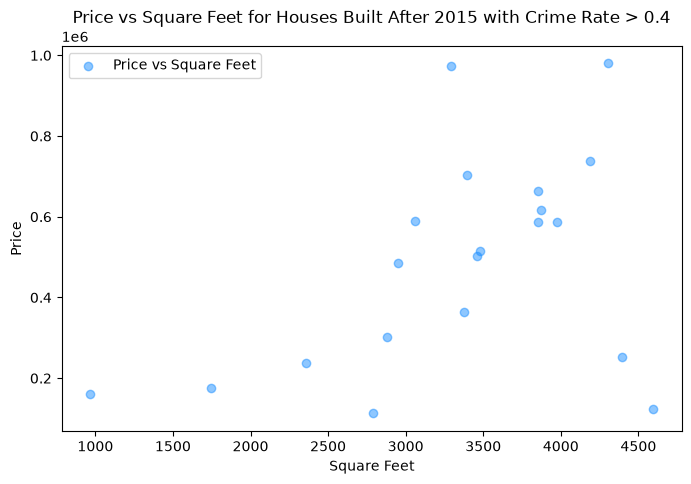

In [7]:
plt.figure(figsize=(8,5))
plt.scatter(df['SquareFeet'], df['Price'], color='dodgerblue', alpha=0.5, label='Price vs Square Feet')
plt.title('Price vs Square Feet for Houses Built After 2015 with Crime Rate > 0.4')
plt.xlabel('Square Feet')
plt.ylabel('Price')
plt.legend()

#### 3.2 모델 학습 및 결과 시각화

특성(Feature, 방 면적)과 정답(Label, 집값) 나누기

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import sklearn
sklearn.set_config(display="text")

In [19]:
X = df[['SquareFeet']]
y = df[['Price']]
print(X.shape, y.shape)
print(len(X), len(y))

(20, 1) (20, 1)
20 20


선형 회귀 모델 준비 및 학습(fit)
 - fit(특성(feature), 레이블(Label)) : 학습을 진행

In [45]:
model = LinearRegression()
model.fit(X, y)

print(model.coef_, model.intercept_)

[[131.03221864]] [46118.85583881]


학습된 모델로 집값 예측해보기
- predict(...) : 예측

In [37]:
y_pred = model.predict(X=X)
y_pred

array([[595274.88417525],
       [551117.02649227],
       [432794.93305686],
       [491235.30257202],
       [567233.98938546],
       [551379.09092956],
       [648473.96494466],
       [553475.60642786],
       [610474.62153794],
       [411698.7458552 ],
       [447339.50932633],
       [423360.6133145 ],
       [477214.85517713],
       [172433.9146115 ],
       [274508.01293507],
       [621874.42455996],
       [354699.73074511],
       [488090.52932457],
       [499097.23569065],
       [502242.00893811]])

오차 점수 확인하기

In [ ]:
mse = mean_squared_error(y, y_pred=y_pred)
mae = mean_absolute_error(y, y_pred=y_pred)

print("MSE:", mse)
print("MSA:", mae)  

MSE: 52237670891.55161
MSA: 166470.19362905624


모델이 찾은 직선 그래프로 그려보기

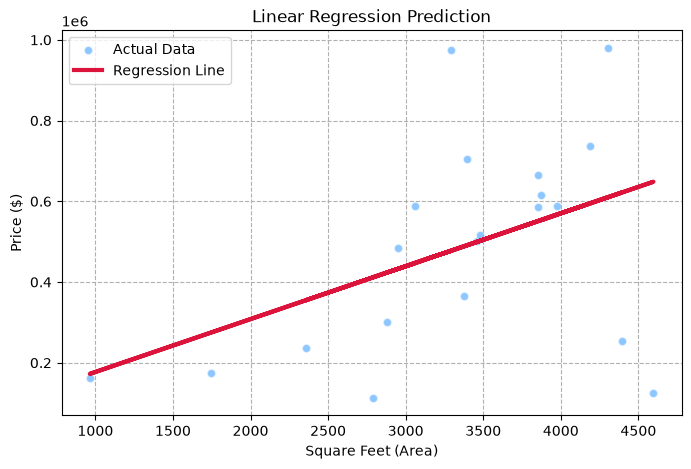

In [40]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='dodgerblue', alpha=0.5, edgecolor='w', label='Actual Data')
plt.plot(X, y_pred, color='crimson', linewidth=3, label='Regression Line')
plt.title('Linear Regression Prediction')
plt.xlabel('Square Feet (Area)')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()